# Cortical representations of languages during natural dialogue

## figure 5 - results of principal component analysis

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import h5py
from matplotlib import pyplot as plt
import japanize_matplotlib
import os
import matplotlib.font_manager as fm
import pprint
%matplotlib inline

cm = 1/2.54


LLM='CHATGPTNEOX'


# directroy 
datadir=os.getcwd()+'../../derivative/preprocessed/{subj}/'
savedir=os.getcwd()+'../../results/'


## Figure 5 b, e (partial correlation between Morpheme/Syllable and PC)

In [11]:
csvfile=f'{savedir}PCA_Result_CHATGPTNEOX_Prod_lowlevel_PC_vs_LowLevelFeatures.csv'
df_prod = pd.read_csv(csvfile, index_col=0)

csvfile=f'{savedir}PCA_Result_CHATGPTNEOX_Comp_lowlevel_PC_vs_LowLevelFeatures.csv'
df_comp = pd.read_csv(csvfile, index_col=0)


In [60]:
figsize=3
figbottom=1.8
linewidth=0.5
dpi=150
color='BrBG'
smax=0.5

plt.style.use('default')
plt.rcParams["font.size"] = 6
plt.rcParams['font.family'] = "Arial"

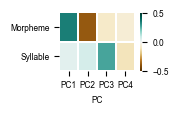

PC             PC1       PC2       PC3       PC4
Morpheme  0.348060 -0.382290 -0.089278 -0.062792
Syllable  0.040824  0.068972  0.276920 -0.110500


In [13]:
name='Prod'

figfile=f'{savedir}PCA_Result_{LLM}_{name}_lowlevel_PC_vs_LowLevelFeatures.pdf'
figfile=f'{savedir}PCA_Result_{LLM}_{name}_lowlevel_PC_vs_LowLevelFeatures_test.pdf'

plt.figure(figsize=(figsize*cm, figbottom*cm))
ax=sns.heatmap(df_prod.T, annot=False, linewidth=linewidth, vmin=-smax, vmax=smax, center=0, square=False, cbar=True, cmap=color)

plt.subplots_adjust(left=0.12, right=0.92, bottom=0.15, top=0.97)
plt.savefig(figfile, dpi=dpi)
plt.show()
plt.close('all')

print(df_prod.T)


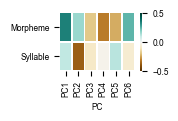

PC            PC1      PC2       PC3       PC4      PC5       PC6
Morpheme  0.34687  0.16219 -0.182150 -0.310340 -0.23296  0.245900
Syllable  0.10931 -0.36863 -0.092371 -0.019996  0.11861 -0.070831


In [14]:
name='Comp'

figfile=f'{savedir}PCA_Result_{LLM}_{name}_lowlevel_PC_vs_LowLevelFeatures.pdf'
figfile=f'{savedir}PCA_Result_{LLM}_{name}_lowlevel_PC_vs_LowLevelFeatures_test.pdf'

plt.figure(figsize=(figsize*cm, figbottom*cm))
ax=sns.heatmap(df_comp.T, annot=False, linewidth=linewidth, vmin=-smax, vmax=smax, center=0, square=False, cbar=True, cmap=color)

plt.subplots_adjust(left=0.12, right=0.92, bottom=0.15, top=0.97)
plt.savefig(figfile, dpi=dpi)
plt.show()
plt.close('all')

print(df_comp.T)


## figure 5c, f (Correlation coefficient between Part-of-speech weights and PC scores)

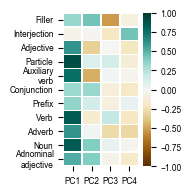

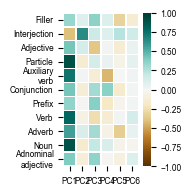

In [61]:
## After FreeConv_analyze_pos_weights_concat(2)

##  part-of-speech vs. stim
modalities=['Prod', 'Comp']
cluster_name=['Filler', 'Interjection', 'Adjective', 'Particle', 
          'Auxiliary\nverb', 'Conjunction', 'Prefix', 'Verb', 'Adverb', 'Noun', 'Adnominal\nadjective']

for modality in modalities:
    ## load correlation coefficient results
    corr_file=f'{savedir}GroupMean_Corr_PCA_vs_POS_{LLM}_{modality}.mat'
    f = h5py.File(corr_file,'r')
    corr = np.array(f.get('group_meanR'))
    
    ## file size, number of significant PCs
    if modality == 'Prod':
        idx_name= ['PC1','PC2','PC3','PC4']
        fig_size=(4.5*cm, 5*cm)
    else:
        idx_name= ['PC1','PC2','PC3','PC4','PC5','PC6']
        fig_size=(4.5*cm, 5*cm)
    
    
    df=pd.DataFrame(data=corr, index=cluster_name, columns=idx_name, dtype=float)

    # heatmap 
    plt.rcParams["font.size"] = 6
    plt.rcParams['font.family'] = "Arial"
    plt.rcParams["lines.linewidth"] = 0.5
    
    plt.figure(figsize=fig_size) 
    figfile=f'{savedir}GroupMean_Corr_PCA_vs_POS_{LLM}_{modality}_test.pdf'
    ax=sns.heatmap(df, linewidths=.5, vmin=-1, vmax=1, square=False, cmap=color, cbar=True)
    plt.subplots_adjust(left=0.32, right=0.85, bottom=0.1)
    plt.savefig(figfile, dpi=dpi)
    plt.show()
    plt.close('all')


## figure 5g, h (scatter plot between two PC dimensions)

### Manually selected common phrases

In [39]:
idx='eg'
figsize=8.9
figbottom=6
fontsize=6.5
blank_space=0.05

dpi=300
letter_alpha=1
linewidth=1

fontname="Arial"
plt.rcParams['font.family'] = "Arial"
plt.rcParams['font.weight'] = 'bold'

plt.style.use('default')
plt.style.use('dark_background')

select_num=30

### Production PC

In [40]:
prefix='Production'
modality='Prod'

    
## PC loading of utterances
utt_pc_file=f'{savedir}PCload_{LLM}_{modality}.mat'
f = h5py.File(utt_pc_file,'r')
utt_pc = np.array(f.get('utt_pc'))


## utterances that were translated into English
utt_uniq_file=f'{savedir}Unique_utterances_{modality}.txt'
f = open(utt_uniq_file, 'r')
annotations = f.readlines()

loadName_tmp=savedir+f'PCload_{LLM}_{modality}_RGB_'


## color - R
color_file=f'{loadName_tmp}R.txt'
with open(color_file, 'r') as f:
    color = f.read().splitlines()
R = [float(c) for c in color]

## color - G
color_file=f'{loadName_tmp}G.txt'
with open(color_file, 'r') as f:
    color = f.read().splitlines()
G = [float(c) for c in color]

## color - B
color_file=f'{loadName_tmp}B.txt'
with open(color_file, 'r') as f:
    color = f.read().splitlines()
B = [float(c) for c in color]


# convert list to numpy array
annotations = np.array(annotations)
R = np.array(R)
G = np.array(G)
B = np.array(B)



# manually selected utterances
utt_uniq_file=f'{savedir}PCload_{LLM}_{modality}_sample_utt.txt'
f = open(utt_uniq_file, 'r')
annot_selected = f.readlines()


## manually selected utterance index and extract the RGB values
sample_file=f'{savedir}PCload_{LLM}_{modality}_sample_number.txt'
tmp_sample=np.loadtxt(sample_file, dtype='i8')
tmp_sample= tmp_sample-1


utt_pc = utt_pc[tmp_sample,:]
annotations = annotations[tmp_sample]
R = R[tmp_sample]
G = G[tmp_sample]
B = B[tmp_sample]


V=annot_selected


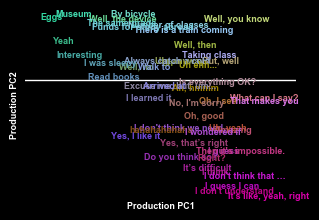

In [47]:
# plot PC1 vs PC2
a=1
b=a+1

## Current data 
X=utt_pc[:,a-1]
Y=utt_pc[:,b-1]
x_name='PC'+str(a)
y_name='PC'+str(b)


## plot annotate for each utterance
plt.rcParams['font.family'] = "Arial"
plt.rcParams['font.weight'] = 'bold'

fig, ax = plt.subplots(facecolor='black', figsize=(figsize*cm, figbottom*cm))
plt.xlim(X.min()-blank_space*0.1, X.max()+blank_space*0.1)
plt.ylim(Y.min(), Y.max())
plt.xlabel(prefix+' '+x_name, fontsize=fontsize, fontname=fontname, fontweight="bold")
plt.ylabel(prefix+' '+y_name, fontsize=fontsize, fontname=fontname, fontweight="bold")

for i, label in enumerate(annot_selected):
    color=(R[i], G[i], B[i])
    plt.annotate(label.rstrip('\n'), (X[i], Y[i]), size=fontsize, color=color, alpha=letter_alpha, ha='center', va='center')

## erase lines
spines=0
ax.spines["top"].set_linewidth(spines)
ax.spines["bottom"].set_linewidth(spines)
ax.spines["left"].set_linewidth(spines)
ax.spines["right"].set_linewidth(spines)


## axis
plt.axhline(0, c='white', linewidth=linewidth)
plt.axvline(0, c='white', linewidth=linewidth)


## no tick
plt.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False, bottom=False, left=False, right=False, top=False)


## save file
loadName_tmp=f'{savedir}PCload_{LLM}_{modality}_sample_{select_num}'
scat_file=f'{loadName_tmp}_RGB_{x_name}_{y_name}_{idx}.pdf'
plt.savefig(scat_file, facecolor="black", format="pdf", dpi=dpi)
plt.show()


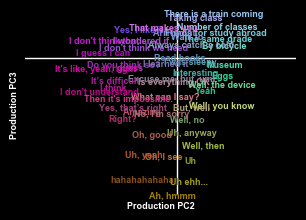

In [49]:
# plot PC2 vs PC3
a=2
b=a+1

## Current data 
X=utt_pc[:,a-1]
Y=utt_pc[:,b-1]
x_name='PC'+str(a)
y_name='PC'+str(b)


## plot annotate for each utterance
plt.rcParams['font.family'] = "Arial"
plt.rcParams['font.weight'] = 'bold'

fig, ax = plt.subplots(facecolor='black', figsize=(figsize*cm, figbottom*cm))
plt.xlim(X.min()-blank_space, X.max()+blank_space)
plt.ylim(Y.min(), Y.max())
plt.xlabel(prefix+' '+x_name, fontsize=fontsize, fontname=fontname, fontweight="bold")
plt.ylabel(prefix+' '+y_name, fontsize=fontsize, fontname=fontname, fontweight="bold")

for i, label in enumerate(annot_selected):
    color=(R[i], G[i], B[i])
    plt.annotate(label.rstrip('\n'), (X[i], Y[i]), size=fontsize, color=color, alpha=letter_alpha, ha='center', va='center')

## erase lines
spines=0
ax.spines["top"].set_linewidth(spines)
ax.spines["bottom"].set_linewidth(spines)
ax.spines["left"].set_linewidth(spines)
ax.spines["right"].set_linewidth(spines)


## axis
plt.axhline(0, c='white', linewidth=linewidth)
plt.axvline(0, c='white', linewidth=linewidth)


## no tick
plt.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False, bottom=False, left=False, right=False, top=False)


## save file
loadName_tmp=f'{savedir}PCload_{LLM}_{modality}_sample_{select_num}'
scat_file=f'{loadName_tmp}_RGB_{x_name}_{y_name}_{idx}.pdf'
plt.savefig(scat_file, facecolor="black", format="pdf", dpi=dpi)
plt.show()


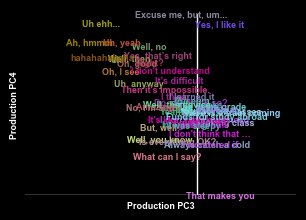

In [50]:
# plot PC3 vs PC4
a=3
b=a+1

## Current data 
X=utt_pc[:,a-1]
Y=utt_pc[:,b-1]
x_name='PC'+str(a)
y_name='PC'+str(b)


## plot annotate for each utterance
plt.rcParams['font.family'] = "Arial"
plt.rcParams['font.weight'] = 'bold'

fig, ax = plt.subplots(facecolor='black', figsize=(figsize*cm, figbottom*cm))
plt.xlim(X.min()-blank_space, X.max()+blank_space)
plt.ylim(Y.min(), Y.max())
plt.xlabel(prefix+' '+x_name, fontsize=fontsize, fontname=fontname, fontweight="bold")
plt.ylabel(prefix+' '+y_name, fontsize=fontsize, fontname=fontname, fontweight="bold")

for i, label in enumerate(annot_selected):
    color=(R[i], G[i], B[i])
    plt.annotate(label.rstrip('\n'), (X[i], Y[i]), size=fontsize, color=color, alpha=letter_alpha, ha='center', va='center')

## erase lines
spines=0
ax.spines["top"].set_linewidth(spines)
ax.spines["bottom"].set_linewidth(spines)
ax.spines["left"].set_linewidth(spines)
ax.spines["right"].set_linewidth(spines)


## axis
plt.axhline(0, c='white', linewidth=linewidth)
plt.axvline(0, c='white', linewidth=linewidth)


## no tick
plt.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False, bottom=False, left=False, right=False, top=False)


## save file
loadName_tmp=f'{savedir}PCload_{LLM}_{modality}_sample_{select_num}'
scat_file=f'{loadName_tmp}_RGB_{x_name}_{y_name}_{idx}.pdf'
plt.savefig(scat_file, facecolor="black", format="pdf", dpi=dpi)
plt.show()


### Comprehension PC

In [51]:

prefix='Comprehension'
modality='Comp'

    
## PC loading of utterances
utt_pc_file=f'{savedir}PCload_{LLM}_{modality}.mat'
f = h5py.File(utt_pc_file,'r')
utt_pc = np.array(f.get('utt_pc'))


## utterances that were translated into English
utt_uniq_file=f'{savedir}Unique_utterances_{modality}.txt'
f = open(utt_uniq_file, 'r')
annotations = f.readlines()

loadName_tmp=savedir+f'PCload_{LLM}_{modality}_RGB_'


## color - R
color_file=f'{loadName_tmp}R.txt'
with open(color_file, 'r') as f:
    color = f.read().splitlines()
R = [float(c) for c in color]

## color - G
color_file=f'{loadName_tmp}G.txt'
with open(color_file, 'r') as f:
    color = f.read().splitlines()
G = [float(c) for c in color]

## color - B
color_file=f'{loadName_tmp}B.txt'
with open(color_file, 'r') as f:
    color = f.read().splitlines()
B = [float(c) for c in color]


# convert list to numpy array
annotations = np.array(annotations)
R = np.array(R)
G = np.array(G)
B = np.array(B)



# manually selected utterances
utt_uniq_file=f'{savedir}PCload_{LLM}_{modality}_sample_utt.txt'
f = open(utt_uniq_file, 'r')
annot_selected = f.readlines()


## manually selected utterance index and extract the RGB values
sample_file=f'{savedir}PCload_{LLM}_{modality}_sample_number.txt'
tmp_sample=np.loadtxt(sample_file, dtype='i8')
tmp_sample= tmp_sample-1


utt_pc = utt_pc[tmp_sample,:]
annotations = annotations[tmp_sample]
R = R[tmp_sample]
G = G[tmp_sample]
B = B[tmp_sample]



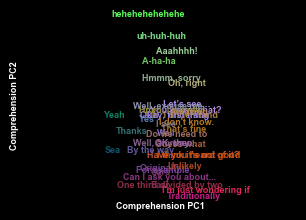

In [53]:
# plot PC1 vs PC2
a=1
b=a+1

## Current data 
X=utt_pc[:,a-1]
Y=utt_pc[:,b-1]
x_name='PC'+str(a)
y_name='PC'+str(b)


## plot annotate for each utterance
plt.rcParams['font.family'] = "Arial"
plt.rcParams['font.weight'] = 'bold'

fig, ax = plt.subplots(facecolor='black', figsize=(figsize*cm, figbottom*cm))
plt.xlim(X.min()-blank_space, X.max()+blank_space)
plt.ylim(Y.min(), Y.max())
plt.xlabel(prefix+' '+x_name, fontsize=fontsize, fontname=fontname, fontweight="bold")
plt.ylabel(prefix+' '+y_name, fontsize=fontsize, fontname=fontname, fontweight="bold")

for i, label in enumerate(annot_selected):
    color=(R[i], G[i], B[i])
    plt.annotate(label.rstrip('\n'), (X[i], Y[i]), size=fontsize, color=color, alpha=letter_alpha, ha='center', va='center')

## erase lines
spines=0
ax.spines["top"].set_linewidth(spines)
ax.spines["bottom"].set_linewidth(spines)
ax.spines["left"].set_linewidth(spines)
ax.spines["right"].set_linewidth(spines)


## axis
plt.axhline(0, c='white', linewidth=linewidth)
plt.axvline(0, c='white', linewidth=linewidth)


## no tick
plt.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False, bottom=False, left=False, right=False, top=False)


## save file
loadName_tmp=f'{savedir}PCload_{LLM}_{modality}_sample_{select_num}'
scat_file=f'{loadName_tmp}_RGB_{x_name}_{y_name}_{idx}.pdf'
plt.savefig(scat_file, facecolor="black", format="pdf", dpi=dpi)
plt.show()


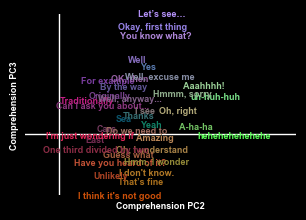

In [52]:
# plot PC2 vs PC3
a=2
b=a+1

## Current data 
X=utt_pc[:,a-1]
Y=utt_pc[:,b-1]
x_name='PC'+str(a)
y_name='PC'+str(b)


## plot annotate for each utterance
plt.rcParams['font.family'] = "Arial"
plt.rcParams['font.weight'] = 'bold'

fig, ax = plt.subplots(facecolor='black', figsize=(figsize*cm, figbottom*cm))
plt.xlim(X.min()-blank_space, X.max()+blank_space)
plt.ylim(Y.min(), Y.max())
plt.xlabel(prefix+' '+x_name, fontsize=fontsize, fontname=fontname, fontweight="bold")
plt.ylabel(prefix+' '+y_name, fontsize=fontsize, fontname=fontname, fontweight="bold")

for i, label in enumerate(annot_selected):
    color=(R[i], G[i], B[i])
    plt.annotate(label.rstrip('\n'), (X[i], Y[i]), size=fontsize, color=color, alpha=letter_alpha, ha='center', va='center')

## erase lines
spines=0
ax.spines["top"].set_linewidth(spines)
ax.spines["bottom"].set_linewidth(spines)
ax.spines["left"].set_linewidth(spines)
ax.spines["right"].set_linewidth(spines)


## axis
plt.axhline(0, c='white', linewidth=linewidth)
plt.axvline(0, c='white', linewidth=linewidth)


## no tick
plt.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False, bottom=False, left=False, right=False, top=False)


## save file
loadName_tmp=f'{savedir}PCload_{LLM}_{modality}_sample_{select_num}'
scat_file=f'{loadName_tmp}_RGB_{x_name}_{y_name}_{idx}.pdf'
plt.savefig(scat_file, facecolor="black", format="pdf", dpi=dpi)
plt.show()


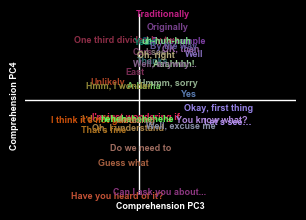

In [54]:
# plot PC3 vs PC4
a=3
b=a+1

## Current data 
X=utt_pc[:,a-1]
Y=utt_pc[:,b-1]
x_name='PC'+str(a)
y_name='PC'+str(b)


## plot annotate for each utterance
plt.rcParams['font.family'] = "Arial"
plt.rcParams['font.weight'] = 'bold'

fig, ax = plt.subplots(facecolor='black', figsize=(figsize*cm, figbottom*cm))
plt.xlim(X.min()-blank_space, X.max()+blank_space)
plt.ylim(Y.min(), Y.max())
plt.xlabel(prefix+' '+x_name, fontsize=fontsize, fontname=fontname, fontweight="bold")
plt.ylabel(prefix+' '+y_name, fontsize=fontsize, fontname=fontname, fontweight="bold")

for i, label in enumerate(annot_selected):
    color=(R[i], G[i], B[i])
    plt.annotate(label.rstrip('\n'), (X[i], Y[i]), size=fontsize, color=color, alpha=letter_alpha, ha='center', va='center')

## erase lines
spines=0
ax.spines["top"].set_linewidth(spines)
ax.spines["bottom"].set_linewidth(spines)
ax.spines["left"].set_linewidth(spines)
ax.spines["right"].set_linewidth(spines)


## axis
plt.axhline(0, c='white', linewidth=linewidth)
plt.axvline(0, c='white', linewidth=linewidth)


## no tick
plt.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False, bottom=False, left=False, right=False, top=False)


## save file
loadName_tmp=f'{savedir}PCload_{LLM}_{modality}_sample_{select_num}'
scat_file=f'{loadName_tmp}_RGB_{x_name}_{y_name}_{idx}.pdf'
plt.savefig(scat_file, facecolor="black", format="pdf", dpi=dpi)
plt.show()


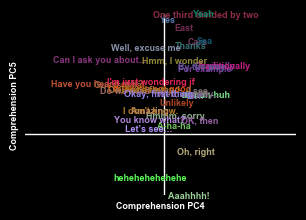

In [55]:
# plot PC4 vs PC5
a=4
b=a+1

## Current data 
X=utt_pc[:,a-1]
Y=utt_pc[:,b-1]
x_name='PC'+str(a)
y_name='PC'+str(b)


## plot annotate for each utterance
plt.rcParams['font.family'] = "Arial"
plt.rcParams['font.weight'] = 'bold'

fig, ax = plt.subplots(facecolor='black', figsize=(figsize*cm, figbottom*cm))
plt.xlim(X.min()-blank_space, X.max()+blank_space)
plt.ylim(Y.min(), Y.max())
plt.xlabel(prefix+' '+x_name, fontsize=fontsize, fontname=fontname, fontweight="bold")
plt.ylabel(prefix+' '+y_name, fontsize=fontsize, fontname=fontname, fontweight="bold")

for i, label in enumerate(annot_selected):
    color=(R[i], G[i], B[i])
    plt.annotate(label.rstrip('\n'), (X[i], Y[i]), size=fontsize, color=color, alpha=letter_alpha, ha='center', va='center')

## erase lines
spines=0
ax.spines["top"].set_linewidth(spines)
ax.spines["bottom"].set_linewidth(spines)
ax.spines["left"].set_linewidth(spines)
ax.spines["right"].set_linewidth(spines)


## axis
plt.axhline(0, c='white', linewidth=linewidth)
plt.axvline(0, c='white', linewidth=linewidth)


## no tick
plt.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False, bottom=False, left=False, right=False, top=False)


## save file
loadName_tmp=f'{savedir}PCload_{LLM}_{modality}_sample_{select_num}'
scat_file=f'{loadName_tmp}_RGB_{x_name}_{y_name}_{idx}.pdf'
plt.savefig(scat_file, facecolor="black", format="pdf", dpi=dpi)
plt.show()


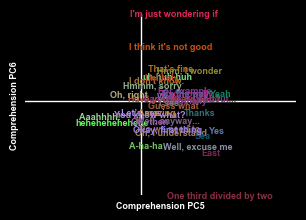

In [56]:
# plot PC5 vs PC6
a=5
b=a+1

## Current data 
X=utt_pc[:,a-1]
Y=utt_pc[:,b-1]
x_name='PC'+str(a)
y_name='PC'+str(b)


## plot annotate for each utterance
plt.rcParams['font.family'] = "Arial"
plt.rcParams['font.weight'] = 'bold'

fig, ax = plt.subplots(facecolor='black', figsize=(figsize*cm, figbottom*cm))
plt.xlim(X.min()-blank_space, X.max()+blank_space)
plt.ylim(Y.min(), Y.max())
plt.xlabel(prefix+' '+x_name, fontsize=fontsize, fontname=fontname, fontweight="bold")
plt.ylabel(prefix+' '+y_name, fontsize=fontsize, fontname=fontname, fontweight="bold")

for i, label in enumerate(annot_selected):
    color=(R[i], G[i], B[i])
    plt.annotate(label.rstrip('\n'), (X[i], Y[i]), size=fontsize, color=color, alpha=letter_alpha, ha='center', va='center')

## erase lines
spines=0
ax.spines["top"].set_linewidth(spines)
ax.spines["bottom"].set_linewidth(spines)
ax.spines["left"].set_linewidth(spines)
ax.spines["right"].set_linewidth(spines)


## axis
plt.axhline(0, c='white', linewidth=linewidth)
plt.axvline(0, c='white', linewidth=linewidth)


## no tick
plt.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False, bottom=False, left=False, right=False, top=False)


## save file
loadName_tmp=f'{savedir}PCload_{LLM}_{modality}_sample_{select_num}'
scat_file=f'{loadName_tmp}_RGB_{x_name}_{y_name}_{idx}.pdf'
plt.savefig(scat_file, facecolor="black", format="pdf", dpi=dpi)
plt.show()
